# Model Comparison for Insurance Fraud Detection

Train and test **all** models (fraud + severity), visualize performance, then save only the **best** models for use in the main project.

**Flow:** Load data -> Preprocess -> Train all models -> Visualize -> Pick best -> Save

## 1. Setup & Load Data

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                            mean_absolute_error, mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
import sys
!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install lightgbm

from ml_pipeline import (load_and_clean_data, prepare_features, _ensure_no_nan,
                        _fraud_models, _severity_models, SEED, TEST_SIZE, N_CV)

BASE_DIR = os.getcwd()  # Run notebook from project folder
UPLOADS = os.path.join(BASE_DIR, "uploads")
CSV_PATH = os.path.join(UPLOADS, "insurance_claims_fraud.csv")

print("Data:", CSV_PATH)
df = load_and_clean_data(CSV_PATH)
print("Rows:", len(df))

Data: c:\Users\Dell\ML Project\uploads\claims_data.csv
Rows: 30000


## 2. Preprocess & Split

In [17]:
prep = prepare_features(df)
if prep is None:
    raise ValueError("prepare_features returned None - check that data has required columns")
X, y_fraud, y_amount, encoders, feature_names, cat_cols, cat_modes = prep
# Same imputation strategy as ml_pipeline, without keep_empty_features to avoid version-specific internals
imputer = SimpleImputer(strategy="median", fill_value=0)
X_imputed = imputer.fit_transform(X)
X_imputed = _ensure_no_nan(X_imputed)

X_train, X_test, yf_train, yf_test, ya_train, ya_test = train_test_split(
    X_imputed, y_fraud, y_amount, test_size=TEST_SIZE, random_state=SEED, stratify=y_fraud
)
ya_train_arr = np.asarray(ya_train, dtype=float)
ya_test_arr = np.asarray(ya_test, dtype=float)
ya_train_log = np.log1p(ya_train_arr)
ya_test_log = np.log1p(ya_test_arr)

print("Train:", len(X_train), "Test:", len(X_test))
print("Features:", len(feature_names))

Train: 24000 Test: 6000
Features: 22


## 3. Train All Fraud Models

In [18]:
X_train_f = _ensure_no_nan(X_train)
X_test_f = _ensure_no_nan(X_test)
yf_arr = np.asarray(yf_train, dtype=int)
n_neg = int((yf_arr == 0).sum())
n_pos = max(1, int((yf_arr == 1).sum()))
scale_pos_weight = n_neg / n_pos

fraud_metrics = {}
fraud_models_fit = {}
cv = StratifiedKFold(n_splits=N_CV, shuffle=True, random_state=SEED)

for name, clf in _fraud_models():
    clf = clone(clf)
    if "XGBoost" in name or "LightGBM" in name:
        clf.set_params(scale_pos_weight=scale_pos_weight)
    cv_f1 = cross_val_score(clf, X_train_f, yf_train, cv=cv, scoring="f1", n_jobs=-1).mean()
    clf.fit(X_train_f, yf_train)
    pred = clf.predict(X_test_f)
    fraud_models_fit[name] = clf
    fraud_metrics[name] = {
        "cv_f1": cv_f1,
        "accuracy": accuracy_score(yf_test, pred),
        "precision": precision_score(yf_test, pred, zero_division="warn"),
        "recall": recall_score(yf_test, pred, zero_division="warn"),
        "f1": f1_score(yf_test, pred, zero_division="warn"),
        "roc_auc": roc_auc_score(yf_test, clf.predict_proba(X_test_f)[:, 1]) if hasattr(clf, "predict_proba") else 0,
    }

best_fraud = max(fraud_metrics, key=lambda n: fraud_metrics[n]["cv_f1"])
print("Best fraud (by CV F1, trained on natural class distribution):", best_fraud)
for n, m in fraud_metrics.items():
    print(f"  {n}: CV_F1={m['cv_f1']:.4f}, Test_F1={m['f1']:.4f}, Recall={m['recall']:.4f}")

KeyboardInterrupt: 

## 4. Train All Severity Models

In [9]:
severity_metrics = {}
severity_models_fit = {}

for name, reg in _severity_models():
    reg = clone(reg)
    cv_r2 = cross_val_score(reg, X_train, ya_train_log, cv=N_CV, scoring="r2", n_jobs=-1).mean()
    reg.fit(X_train, ya_train_log)
    pred_log = reg.predict(X_test)
    pred_dollars = np.expm1(pred_log)
    ya_dollars = np.expm1(ya_test_log)
    severity_models_fit[name] = reg
    severity_metrics[name] = {
        "cv_r2": cv_r2,
        "r2": r2_score(ya_test_log, pred_log),
        "mae": mean_absolute_error(ya_dollars, pred_dollars),
        "rmse": np.sqrt(mean_squared_error(ya_dollars, pred_dollars)),
    }

best_severity = max(severity_metrics, key=lambda n: severity_metrics[n]["cv_r2"])
print("Best severity (by CV R2):", best_severity)
for n, m in severity_metrics.items():
    print(f"  {n}: CV_R2={m['cv_r2']:.4f}, Test_R2={m['r2']:.4f}, MAE=${m['mae']:.0f}")

Best severity (by CV R2): Random Forest
  Random Forest: CV_R2=-0.0019, Test_R2=-0.0037, MAE=$5776
  XGBoost: CV_R2=-0.0950, Test_R2=-0.0836, MAE=$5949
  LightGBM: CV_R2=-0.0182, Test_R2=-0.0167, MAE=$5795


## 5. Visualizations

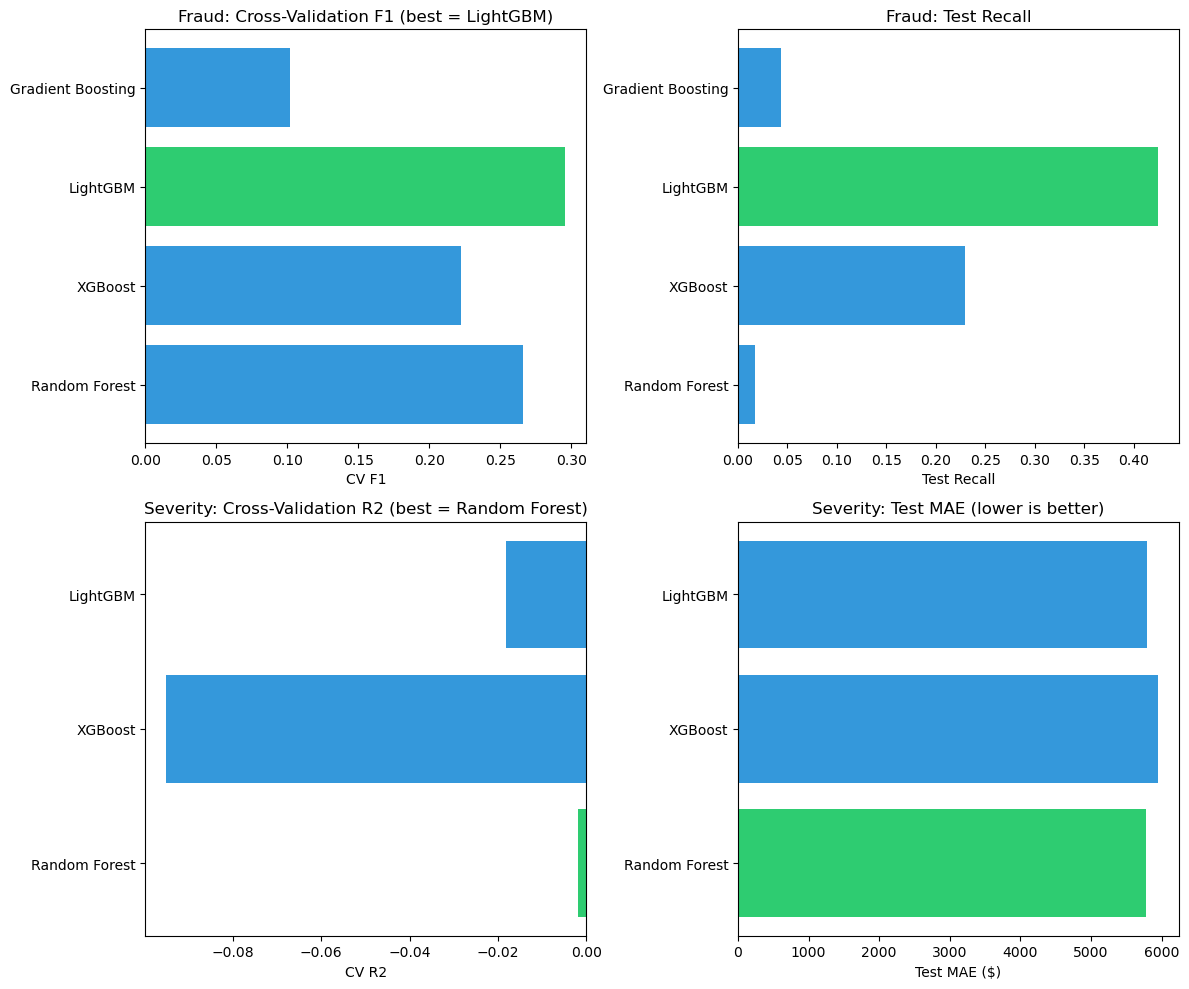

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Fraud: F1
ax = axes[0, 0]
names = list(fraud_metrics.keys())
cv_f1 = [fraud_metrics[n]["cv_f1"] for n in names]
cols = ['#2ecc71' if n == best_fraud else '#3498db' for n in names]
ax.barh(names, cv_f1, color=cols)
ax.set_xlabel("CV F1")
ax.set_title("Fraud: Cross-Validation F1 (best = " + best_fraud + ")")

# Fraud: Recall
ax = axes[0, 1]
rec = [fraud_metrics[n]["recall"] for n in names]
ax.barh(names, rec, color=cols)
ax.set_xlabel("Test Recall")
ax.set_title("Fraud: Test Recall")

# Severity: R2
ax = axes[1, 0]
names_s = list(severity_metrics.keys())
cv_r2 = [severity_metrics[n]["cv_r2"] for n in names_s]
cols_s = ['#2ecc71' if n == best_severity else '#3498db' for n in names_s]
ax.barh(names_s, cv_r2, color=cols_s)
ax.set_xlabel("CV R2")
ax.set_title("Severity: Cross-Validation R2 (best = " + best_severity + ")")

# Severity: MAE
ax = axes[1, 1]
mae = [severity_metrics[n]["mae"] for n in names_s]
ax.barh(names_s, mae, color=cols_s)
ax.set_xlabel("Test MAE ($)")
ax.set_title("Severity: Test MAE (lower is better)")

plt.tight_layout()
plt.show()

## 6. Save Best Models for Main Project

In [11]:
OUTPUT_DIR = os.path.join(BASE_DIR, "trained_models")
os.makedirs(OUTPUT_DIR, exist_ok=True)

best_fraud_clf = fraud_models_fit[best_fraud]
best_severity_reg = severity_models_fit[best_severity]
train_means = {c: float(v) for c, v in pd.DataFrame(X_imputed, columns=feature_names).mean().items()}

joblib.dump(best_fraud_clf, os.path.join(OUTPUT_DIR, f"best_fraud_{best_fraud.replace(' ', '_')}.pkl"))
joblib.dump(best_severity_reg, os.path.join(OUTPUT_DIR, f"best_severity_{best_severity.replace(' ', '_')}.pkl"))

store = {
    "fraud_model": best_fraud_clf,
    "severity_model": best_severity_reg,
    "feature_names": feature_names,
    "train_means": train_means,
    "imputer": imputer,
    "encoders": encoders,
    "cat_modes": cat_modes,
    "fraud_threshold": 0.35,
    "best_fraud_name": best_fraud,
    "best_severity_name": best_severity,
    "severity_log_target": True,
}
joblib.dump(store, os.path.join(OUTPUT_DIR, "full_store.pkl"))

print("Saved to", OUTPUT_DIR)
print("Best fraud:", best_fraud)
print("Best severity:", best_severity)
print("-> Your main project will use these when you run the app.")

Saved to c:\Users\Dell\ML Project\trained_models
Best fraud: LightGBM
Best severity: Random Forest
-> Your main project will use these when you run the app.


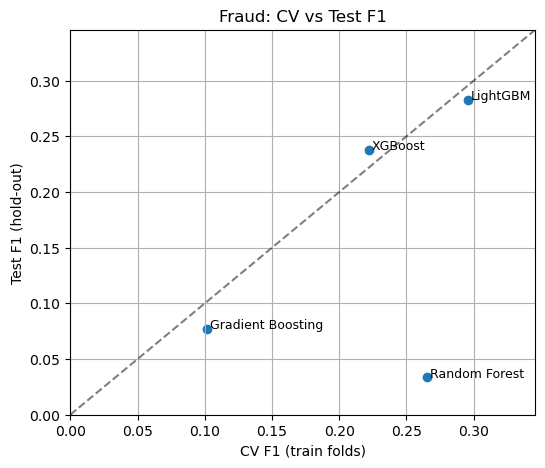

In [12]:
# 5a. Fraud: CV vs Test F1 (over/underfit check)
names = list(fraud_metrics.keys())
cv_f1 = [fraud_metrics[n]["cv_f1"] for n in names]
test_f1 = [fraud_metrics[n]["f1"] for n in names]

plt.figure(figsize=(6, 5))
plt.scatter(cv_f1, test_f1)
for n, x, y in zip(names, cv_f1, test_f1):
    plt.text(x + 0.002, y, n, fontsize=9)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("CV F1 (train folds)")
plt.ylabel("Test F1 (hold-out)")
plt.title("Fraud: CV vs Test F1")
plt.xlim(0, max(cv_f1 + test_f1) + 0.05)
plt.ylim(0, max(cv_f1 + test_f1) + 0.05)
plt.grid(True)
plt.show()

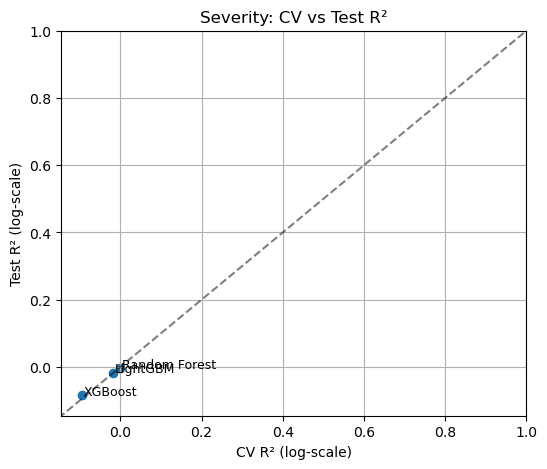

In [13]:
# 5b. Severity: CV vs Test R²
names_s = list(severity_metrics.keys())
cv_r2 = [severity_metrics[n]["cv_r2"] for n in names_s]
test_r2 = [severity_metrics[n]["r2"] for n in names_s]

plt.figure(figsize=(6, 5))
plt.scatter(cv_r2, test_r2)
for n, x, y in zip(names_s, cv_r2, test_r2):
    plt.text(x + 0.005, y, n, fontsize=9)
plt.plot([-0.5, 1], [-0.5, 1], "k--", alpha=0.5)
plt.xlabel("CV R² (log-scale)")
plt.ylabel("Test R² (log-scale)")
plt.title("Severity: CV vs Test R²")
plt.xlim(min(cv_r2 + test_r2) - 0.05, 1)
plt.ylim(min(cv_r2 + test_r2) - 0.05, 1)
plt.grid(True)
plt.show()

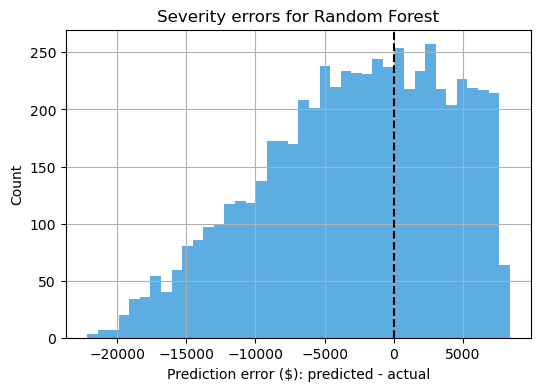

Mean error: -2821.975819477108
MAE: 5775.980916201589


In [14]:
# 5c. Severity error distribution (best model)
best_sev = best_severity
reg = severity_models_fit[best_sev]

pred_log = reg.predict(X_test)
pred_dollars = np.expm1(pred_log)
ya_dollars = np.expm1(ya_test_log)
errors = pred_dollars - ya_dollars

plt.figure(figsize=(6, 4))
plt.hist(errors, bins=40, color="#3498db", alpha=0.8)
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Prediction error ($): predicted - actual")
plt.ylabel("Count")
plt.title(f"Severity errors for {best_sev}")
plt.grid(True)
plt.show()

print("Mean error:", float(errors.mean()))
print("MAE:", float(np.abs(errors).mean()))

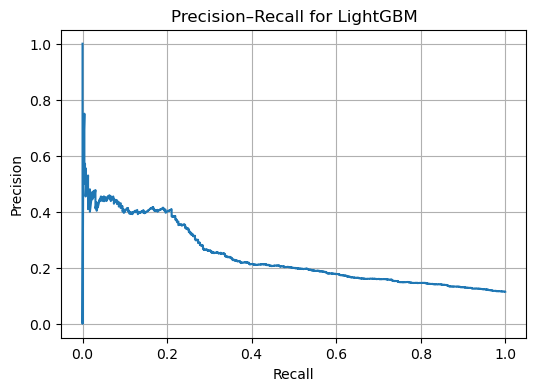

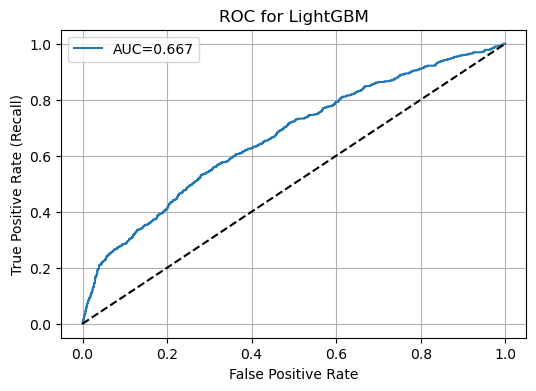

In [15]:
# 5d. Fraud curves (Precision–Recall and ROC) for best model
from sklearn.metrics import precision_recall_curve, roc_curve, auc

clf = fraud_models_fit[best_fraud]
probs = clf.predict_proba(X_test_f)[:, 1]

# Precision–Recall
prec, rec, thr = precision_recall_curve(yf_test, probs)
plt.figure(figsize=(6, 4))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall for {best_fraud}")
plt.grid(True)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(yf_test, probs)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC={auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title(f"ROC for {best_fraud}")
plt.legend()
plt.grid(True)
plt.show()